# Sliding-window decoding

A monolithic decoder waits for the complete detector history and solves one decoding problem for the entire experiment.
For a long-running computation, both the stored history and the time before a correction is committed can become impractical.
`SlidingWindowDecoder` instead processes overlapping intervals of detector time, commits corrections from the leading part of each window, and carries their effect into the next window.

This notebook applies that strategy to qLDPC memory circuits, whose first detector coordinate is the syndrome-measurement round.
For a circuit that uses another coordinate convention, pass `detector_to_time` explicitly instead of relying on automatic inference.


## Setup

Run the next cell once in a fresh notebook environment.
IPython's `%pip` magic installs into the active kernel, so the following imports use the same environment.


In [1]:
%%capture
%pip install qldpc matplotlib

In [2]:
import os
from collections.abc import Sequence

import matplotlib.pyplot as plt
import numpy as np
import sinter
from matplotlib.axes import Axes
from matplotlib.figure import Figure
from matplotlib.ticker import MaxNLocator

from qldpc import circuits, codes, decoders

NUM_WORKERS = max(1, min(4, (os.cpu_count() or 1) - 1))

## Build windowed tasks

The `run_windowed_memory_experiments` method below takes a sequence of `(code, window_size, stride)` tuples.
`window_size` is the number of syndrome-measurement rounds decoded together, and `stride` is the number of rounds committed before the window advances.
The examples below use each surface code's known exact distance as the window size and `distance // 2` as the stride.


In [3]:
def code_label(code: codes.CSSCode) -> str:
    """Return a compact quantum-code parameter label for a plot legend."""
    known_distance = code.get_distance_if_known()
    suffix = f", {known_distance}" if known_distance is not None else ""
    return f"[[{len(code)}, {code.dimension}{suffix}]]"


def run_windowed_memory_experiments(
    decoder_specs: Sequence[tuple[codes.CSSCode, int, int]],
    *,
    error_rates: Sequence[float] = tuple(np.logspace(-3, -2, 5)),
    num_windows: int = 5,
    max_shots: int = 20_000,
    max_errors: int = 100,
    decoder: decoders.DeferredErrorDecoderInput = None,
) -> list[sinter.TaskStats]:
    """Sample sliding-window memory experiments over decoder configurations."""
    tasks = []
    custom_decoders = {}

    for code_index, (code, window_size, stride) in enumerate(decoder_specs):
        num_rounds = num_windows * window_size
        parts = circuits.get_memory_experiment_parts(
            code,
            basis=None,
            num_rounds=num_rounds,
        )
        detectors_x = parts.detector_record.get_events(*parts.qubit_ids.checks_x)
        detectors_z = parts.detector_record.get_events(*parts.qubit_ids.checks_z)

        decoder_name = f"windowed_{code_index}"
        custom_decoders[decoder_name] = decoders.SlidingWindowDecoder(
            window_size,
            stride,
            (detectors_x, detectors_z),
            decoder=decoder,
        )

        for probability in error_rates:
            noise = circuits.DepolarizingNoiseModel(
                probability,
                include_idling_error=False,
            )
            tasks.append(
                sinter.Task(
                    circuit=(
                        parts.initialization + noise.noisy_circuit(parts.qec_cycle) + parts.readout
                    ),
                    decoder=decoder_name,
                    json_metadata={
                        "label": code_label(code),
                        "probability": probability,
                        "rounds": num_rounds,
                    },
                )
            )

    return sinter.collect(
        tasks=tasks,
        custom_decoders=custom_decoders,
        num_workers=NUM_WORKERS,
        max_shots=max_shots,
        max_errors=max_errors,
        print_progress=False,
    )


def plot_windowed_error_rates(
    decoder_specs: Sequence[tuple[codes.CSSCode, int, int]],
    decoder: decoders.DeferredErrorDecoderInput = None,
) -> tuple[Figure, Axes]:
    """Run and plot logical error rates for sliding-window decoder configurations."""
    stats = run_windowed_memory_experiments(decoder_specs, decoder=decoder)
    figure, axis = plt.subplots(figsize=(5.5, 4.2))
    markers = ("o", "s", "^", "D")
    sinter.plot_error_rate(
        ax=axis,
        stats=stats,
        x_func=lambda stat: stat.json_metadata["probability"],
        group_func=lambda stat: stat.json_metadata["label"],
        failure_units_per_shot_func=lambda stat: stat.json_metadata["rounds"],
        plot_args_func=lambda index, _curve_id: {
            "marker": markers[index % len(markers)],
        },
    )
    reference_rates = sorted({stat.json_metadata["probability"] for stat in stats})
    axis.plot(
        reference_rates,
        reference_rates,
        color="black",
        linestyle=":",
        label=r"$p_{\mathrm{logical}}=p_{\mathrm{physical}}$",
    )
    axis.loglog()
    axis.set_xlabel("physical error rate per operation")
    axis.set_ylabel("estimated logical error rate per round")
    axis.legend(loc="best")
    axis.grid(which="both", alpha=0.3)
    figure.tight_layout()
    return figure, axis

## Surface-code comparison

The X- and Z-check detector indices are passed as separate subsets, so every time window decodes the two CSS sectors independently.


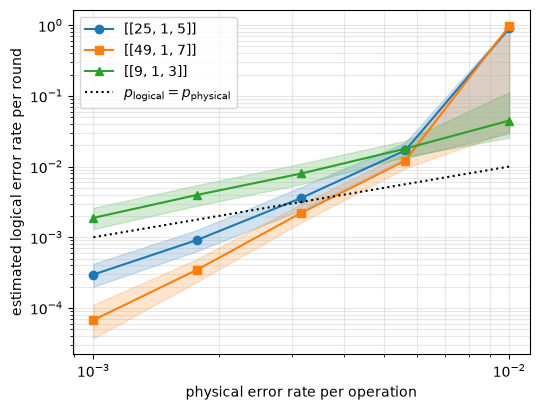

In [4]:
surface_specs = [
    (codes.SurfaceCode(distance, rotated=True), distance, max(1, distance // 2))
    for distance in (3, 5, 7)
]
plot_windowed_error_rates(surface_specs, decoder=decoders.mwpm())
plt.show()

## Check the dependence on experiment length

Expressing failure probability per round makes memory experiments with different durations comparable.
If the normalized estimates approach a common value as the number of rounds grows, initialization and readout boundaries are having a smaller effect over this range.


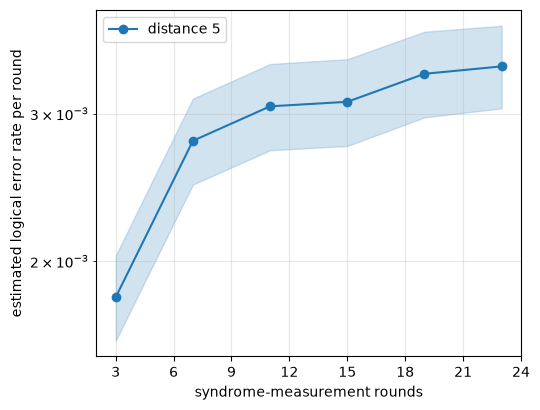

In [5]:
def run_length_sweep(
    code: codes.CSSCode,
    *,
    window_size: int,
    stride: int,
    probability: float = 3e-3,
    round_counts: Sequence[int] = tuple(range(3, 24, 4)),
    max_shots: int = 20_000,
    max_errors: int = 100,
    decoder: decoders.DeferredErrorDecoderInput = None,
) -> list[sinter.TaskStats]:
    """Sample one sliding-window decoder across a range of memory lengths."""
    tasks = []
    custom_decoders = {}

    for num_rounds in round_counts:
        parts = circuits.get_memory_experiment_parts(
            code,
            basis=None,
            num_rounds=num_rounds,
        )
        detector_subsets = (
            parts.detector_record.get_events(*parts.qubit_ids.checks_x),
            parts.detector_record.get_events(*parts.qubit_ids.checks_z),
        )
        decoder_name = f"rounds_{num_rounds}"
        custom_decoders[decoder_name] = decoders.SlidingWindowDecoder(
            window_size,
            stride,
            detector_subsets,
            decoder=decoder,
        )
        noise = circuits.DepolarizingNoiseModel(
            probability,
            include_idling_error=False,
        )
        tasks.append(
            sinter.Task(
                circuit=(
                    parts.initialization + noise.noisy_circuit(parts.qec_cycle) + parts.readout
                ),
                decoder=decoder_name,
                json_metadata={"rounds": num_rounds},
            )
        )

    return sinter.collect(
        tasks=tasks,
        custom_decoders=custom_decoders,
        num_workers=NUM_WORKERS,
        max_shots=max_shots,
        max_errors=max_errors,
        print_progress=False,
    )


surface_code = codes.SurfaceCode(5, rotated=True)
length_stats = run_length_sweep(
    surface_code,
    window_size=5,
    stride=2,
    max_shots=200_000,
    max_errors=1_000,
    decoder=decoders.mwpm(),
)

figure, axis = plt.subplots(figsize=(5.5, 4.2))
sinter.plot_error_rate(
    ax=axis,
    stats=length_stats,
    x_func=lambda stat: stat.json_metadata["rounds"],
    group_func=lambda _stat: "distance 5",
    failure_units_per_shot_func=lambda stat: stat.json_metadata["rounds"],
    plot_args_func=lambda _index, _curve_id: {"marker": "o"},
)
axis.set_yscale("log")
axis.xaxis.set_major_locator(MaxNLocator(integer=True))
axis.set_xlabel("syndrome-measurement rounds")
axis.set_ylabel("estimated logical error rate per round")
axis.legend(loc="best")
axis.grid(which="both", alpha=0.3)
figure.tight_layout()
plt.show()

Window size and stride are accuracy, compute, and latency choices rather than properties of the code alone.
Larger windows give the decoder more temporal context but cost more to solve, while smaller strides increase overlap and commit corrections more gradually.
They should therefore be tuned together with the decoder and the target workload.
